# ICT-2 — Le tri comme morphogenèse minimale (self-sorting arrays)

> Série **ICT — Integrated Causal Trajectories** (Epic #4588), qui prolonge la série **IIT / PyPhi**.

## D'IIT à ICT : de l'état à la trajectoire

La série IIT étudie des **structures causales associées à un état** : matrice de transition (TPM), sous-système, Φ, structure cause-effet. La série ICT déplace le regard vers les **trajectoires** :

$$C_0 \rightarrow C_1 \rightarrow C_2 \rightarrow \dots \rightarrow C_n$$

où chaque $C_t$ résume l'organisation causale du système à l'instant $t$. Les questions deviennent dynamiques : une organisation se **maintient**-elle ? se **répare**-t-elle ? change-t-elle d'**échelle** ? garde-t-elle une **identité** malgré les perturbations ?

Pour entrer dans ce cadre sans la lourdeur calculatoire de PyPhi, ce notebook utilise un **toy model totalement transparent** : le **tri auto-organisé**.

## Le tri vu comme une morphogenèse

D'après :

> Taining Zhang, Adam Goldstein, Michael Levin, *« Classical sorting algorithms as a model of morphogenesis: self-sorting arrays reveal unexpected competencies in a minimal model of basal intelligence »*, **Adaptive Behavior**, 2025 — [arXiv:2401.05375](https://arxiv.org/abs/2401.05375).

L'idée renverse la perspective habituelle du tri. Au lieu d'un **contrôleur global** qui parcourt un tableau et échange des éléments, **chaque élément devient une cellule autonome** qui applique localement la règle de son *algotype*. L'ordre global n'est plus imposé d'en haut : il **émerge** de décisions purement locales. Le tri devient une **trajectoire collective** dans un espace de configurations — une morphogenèse minimale.

Sur ce banc d'essai, tout est calculable et enregistrable, et pourtant des compétences inattendues apparaissent : robustesse aux cellules cassées, sacrifices locaux au service du but global (« délai de gratification »), auto-réparation après lésion. C'est exactement le type de signatures que la série ICT cherche à rendre mesurable.

## Objectifs d'apprentissage

- Comprendre la **vue-cellule** (cell-eye-view) d'un algorithme de tri.
- Enregistrer et visualiser une **trajectoire** dans le morphospace (sortedness, inversions, erreur de monotonie).
- Mesurer trois compétences émergentes : **robustesse**, **délai de gratification**, **auto-réparation**.
- Observer comment l'**hétérogénéité** (tableaux chimériques) crée des impasses locales.

### Prérequis
- Notions de base sur les algorithmes de tri (bubble / insertion).
- Python : `numpy`, `matplotlib` (les structures du modèle sont dans le package local `ict/`).

### Durée estimée : 45 minutes


## Repères IIT — sous-systèmes et structures cause-effet

> Vocabulaire IIT nécessaire pour interpréter ICT-2 (self-sorting morphogenesis) en termes d'information intégrée. Pour Φ/TPM/partition (notions de base), voir [ICT-1](ICT-1-PhiTrajectories.ipynb) § Repères IIT canoniques. Pour le texte fondateur, voir [ICT-0-Annexe](ICT-0-Annexe-IntegratedComplexityTheory.md) ($\Phi_{\text{dyn}}$). Source primaire : [IIT-1 — Intro to PyPhi](../IIT-1-IntroToPyphi.ipynb) + [IIT-2 — Advanced Topics](../IIT-2-AdvancedTopics.ipynb).

ICT-1 calculait $\Phi$ **état par état** sur le système entier. ICT-2 soulève une question plus fine : **quelles parties du tableau qui se trie sont causalement responsables de ce tri ?** Cela exige deux notions que ICT-1 n'introduisait pas :

- **Sous-système (*subsystem*)** — un sous-ensemble $\mathcal{S}' \subseteq \mathcal{S}$ des nœuds du système, avec sa propre TPM marginale (calculée en ignorant les nœuds hors $\mathcal{S}'$). PyPhi représente un sous-système par un masque binaire sur les nœuds : par exemple `0110` sur un système à 4 nœuds = les nœuds 1 et 2 seulement. **Tout système $\mathcal{S}$ a $2^N - 1$ sous-systèmes non vides** ; chaque sous-système a son propre $\Phi_{\mathrm{CE}}$.

- **Information cause-effet ($\Phi_{\mathrm{CE}}$, *cause-effect information*)** — pour un sous-système $\mathcal{S}'$ dans un état donné, c'est l'information que $\mathcal{S}'$ génère *à la fois* vers le passé (ses **causes** : dans quelle mesure l'état passé de $\mathcal{S}'$ est-il contraint par son propre mécanisme, au-dessus et au-delà du reste du système ?) *et* vers le futur (ses **effects** : dans quelle mesure l'état présent de $\mathcal{S}'$ contraint-il son propre futur, au-dessus et au-delà du reste ?). La cause et l'effet sont des distributions de probabilités sur les états antérieurs/postérieurs ; $\Phi_{\mathrm{CE}}$ est la distance EMD entre le système entier et la partition MIP qui sépare $\mathcal{S}'$ du reste.

- **Partition d'un système $\mathcal{S}$ en deux moitiés $\mathcal{S}^L \cup \mathcal{S}^R$** — vue en ICT-1, c'est la brique de calcul de $\Phi_{\mathrm{CE}}$ : PyPhi balaie **toutes les bipartitions dirigées** du système (en plus des sous-systèmes candidats) et retient celle qui **minimise** la divergence entre le système entier et la somme de ses parties — c'est le **MIP** (*Minimum Information Partition*). Pour $N$ nœuds il y a $2^{N-1} - 1$ bipartitions dirigées à comparer (cf ICT-1 « Pourquoi 3 nœuds »).

**Lecture IIT de ICT-2.** Le tableau qui se trie est un système $\mathcal{S}$ à $N$ cellules. À chaque état $s_t$, le **tri en cours** est un certain motif (zones homogènes + frontière). La question IIT est : *quelle est la valeur de $\Phi_{\mathrm{CE}}$ du système $\mathcal{S}$ dans cet état ?* Si $\Phi_{\mathrm{CE}} > 0$, le tableau est **causalement intégré** au-dessus de ses parties — la morphogenèse n'est pas un artefact local mais une structure globale qui contraint passé et futur. Si on bipartitionne en deux moitiés du tableau, on mesure l'information que chaque moitié génère *indépendamment* ; le MIP dit « la partition qui enlève le moins d'intégration possible » — c'est précisément la frontière morphologique. **Un tableau déjà trié a un $\Phi_{\mathrm{CE}}$ plus faible qu'un tableau en train de se trier** : une fois l'ordre établi, les cellules n'ont plus d'information à générer les unes sur les autres (leur état futur est fixé par la règle locale). Un tableau **chimerique** (cell 14-16) qui ne se trie pas, lui, conserve un $\Phi_{\mathrm{CE}}$ non trivial mais reste **piégé** dans un attracteur local — information présente, intégration sans progrès : c'est exactement le type de distinction que la triad IIT/ICT permet de poser.

Ce notebook, comme ICT-1, **n'exécute pas PyPhi** sur les tableaux (le code resterait intraitable pour $N > 5$). Il introduit les concepts pour que ICT-6 (Sorting-to-TPM bridge, à venir) puisse les opérationnaliser sur les simulations.


In [1]:
# --- Imports et configuration ---
import sys, os
sys.path.insert(0, os.path.abspath("."))  # le package `ict/` est a cote de ce notebook

import numpy as np
import matplotlib.pyplot as plt

from ict.self_sorting import SelfSortingArray, ALGOTYPES
from ict import sorting_metrics as m

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
RNG = np.random.default_rng(42)

def perm(k, rng=RNG):
    # une permutation de 0..k-1 en entiers Python natifs (sortie lisible)
    return [int(x) for x in rng.permutation(k)]

print("Algotypes disponibles :", ALGOTYPES)

Algotypes disponibles : ('bubble', 'insertion')


## 1. La vue-cellule : une cellule, une règle locale

Chaque cellule porte une **valeur** (la clé de tri) et un **algotype** (sa règle locale) :

- **`bubble`** : la cellule regarde sa voisine de **droite** ; si elle est plus grande, elle glisse à droite (les grandes valeurs migrent vers la fin).
- **`insertion`** : la cellule regarde sa voisine de **gauche** ; si elle est plus petite, elle glisse à gauche (les petites valeurs migrent vers le début).

Un **planificateur asynchrone seedable** active une cellule au hasard à chaque pas. Il n'y a **aucun contrôleur global** : seulement des cellules qui réagissent à leur voisinage immédiat. Vérifions qu'un tableau homogène se trie de lui-même.

In [2]:
# --- Exemple guide : un tableau homogene (bubble) se trie tout seul ---
valeurs = perm(16)
arr = SelfSortingArray(valeurs, seed=7)   # tous les algotypes = "bubble" par defaut
print("Etat initial :", arr.values)
arr.run()
print("Etat final   :", arr.values)
print(f"Trie ? {arr.values == sorted(valeurs)} | pas={arr.steps} | swaps={arr.probe.swaps}")

Etat initial : [6, 15, 11, 10, 9, 3, 0, 7, 12, 5, 2, 4, 14, 1, 13, 8]
Etat final   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Trie ? True | pas=315 | swaps=68


**Interprétation.** Sans aucune coordination centrale, l'activation aléatoire répétée de cellules qui ne connaissent que leur voisin suffit à atteindre l'ordre global. Chaque échange local **corrige exactement une inversion** : le système ne crée jamais de désordre net, il en élimine. C'est la forme la plus dépouillée d'une morphogenèse — une cible globale atteinte par des règles locales aveugles.

## 2. La trajectoire dans le morphospace

On enregistre, pas à pas, trois mesures :

- **inversions** : nombre de paires dans le mauvais ordre (mesure **globale** du désordre) ;
- **sortedness** $\in [0,1]$ : $1 - \text{inversions} / \binom{n}{2}$ (1 = trié) ;
- **erreur de monotonie** : fraction de paires *adjacentes* en descente (mesure **locale**).

La trajectoire est le voyage du système dans cet espace.

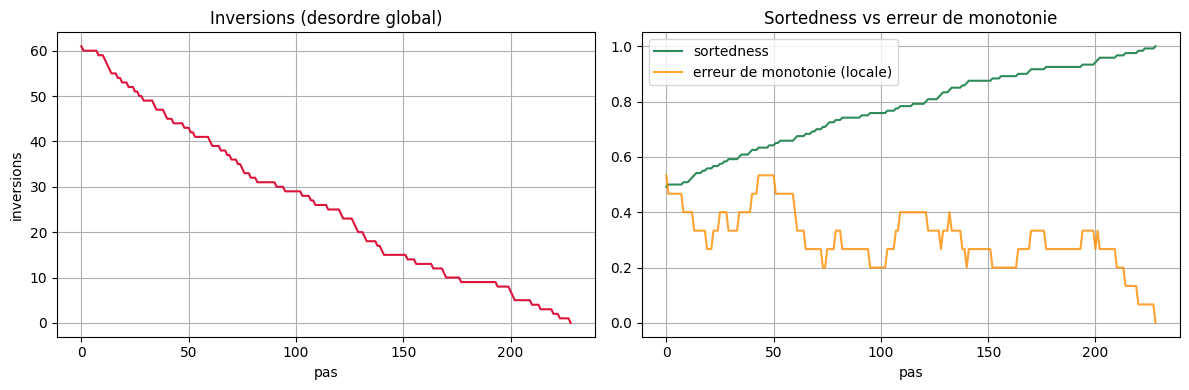

Inversions : 61 -> 0 | pas ou les inversions AUGMENTENT : 0
Erreur de monotonie : episodes ou elle AUGMENTE (delai de gratification) : 17


In [3]:
# --- Exemple guide : trajectoire d'un tri ---
arr = SelfSortingArray(perm(16), seed=11)
arr.run()
inv = m.inversions_curve(arr.probe.values)
srt = m.sortedness_curve(arr.probe.values)
mono = m.monotonicity_curve(arr.probe.values)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(inv, color="crimson"); ax[0].set_title("Inversions (desordre global)")
ax[0].set_xlabel("pas"); ax[0].set_ylabel("inversions")
ax[1].plot(srt, label="sortedness", color="seagreen")
ax[1].plot(mono, label="erreur de monotonie (locale)", color="darkorange", alpha=0.8)
ax[1].set_title("Sortedness vs erreur de monotonie"); ax[1].set_xlabel("pas"); ax[1].legend()
plt.tight_layout(); plt.show()

dg = m.delayed_gratification_events(mono)
inc_inv = sum(1 for a, b in zip(inv, inv[1:]) if b > a)
print(f"Inversions : {inv[0]} -> {inv[-1]} | pas ou les inversions AUGMENTENT : {inc_inv}")
print(f"Erreur de monotonie : episodes ou elle AUGMENTE (delai de gratification) : {dg}")

**Interprétation — le délai de gratification.** Les **inversions** ne remontent jamais (`0` augmentation) : globalement, le système ne recule pas. Mais l'**erreur de monotonie locale**, elle, **augmente transitoirement** à de nombreux pas. Autrement dit, pour faire progresser l'ordre global, le système accepte de **dégrader localement** sa structure — un échange qui résout une inversion peut créer une nouvelle descente chez les voisins. C'est la version structurelle du **délai de gratification** décrit par Zhang, Goldstein & Levin : un système d'agents locaux « accepte d'aller moins bien avant d'aller mieux », sans qu'aucune cellule ne planifie ce sacrifice.

## 3. Robustesse : des cellules défectueuses (frozen)

Une cellule **`frozen`** est *cassée* : elle n'initie jamais d'action. Deux régimes :

- **`passive`** (défaut, fidèle au papier) : elle reste un **passager**, qu'une voisine saine peut déplacer ;
- **`obstacle`** : elle est en plus **infranchissable** (un mur).

Question : jusqu'où le système tolère-t-il des cellules cassées ? Balayons la fraction de cellules gelées et mesurons la sortedness finale (moyenne sur plusieurs graines).

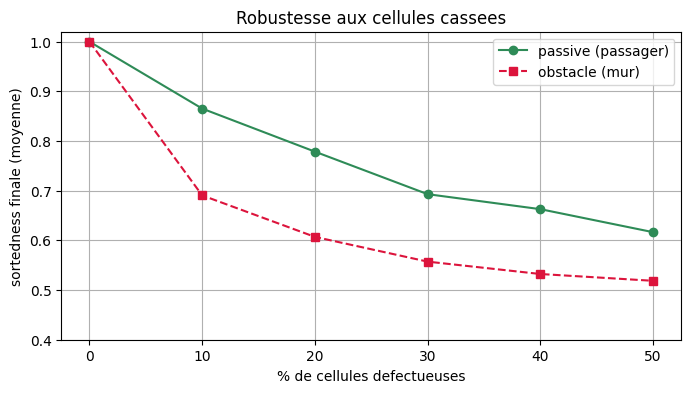

   0% gelees -> passive=1.000 | obstacle=1.000
  10% gelees -> passive=0.865 | obstacle=0.691
  20% gelees -> passive=0.779 | obstacle=0.607
  30% gelees -> passive=0.693 | obstacle=0.557
  40% gelees -> passive=0.663 | obstacle=0.532
  50% gelees -> passive=0.616 | obstacle=0.519


In [4]:
# --- Exemple guide : robustesse passive vs obstacle ---
fracs = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
n = 20
def sweep(mode):
    out = []
    for frac in fracs:
        accs = []
        for s in range(15):
            r = np.random.default_rng(100 + s)
            v = [int(x) for x in r.permutation(n)]
            k = int(round(frac * n))
            fz = [True] * k + [False] * (n - k); r.shuffle(fz)
            a = SelfSortingArray(v, frozen=list(fz), seed=s, frozen_mode=mode).run(record=False)
            accs.append(m.sortedness(a.values))
        out.append(np.mean(accs))
    return out

passive, obstacle = sweep("passive"), sweep("obstacle")
plt.plot([f*100 for f in fracs], passive, "o-", label="passive (passager)", color="seagreen")
plt.plot([f*100 for f in fracs], obstacle, "s--", label="obstacle (mur)", color="crimson")
plt.xlabel("% de cellules defectueuses"); plt.ylabel("sortedness finale (moyenne)")
plt.title("Robustesse aux cellules cassees"); plt.legend(); plt.ylim(0.4, 1.02); plt.show()
for f, p, o in zip(fracs, passive, obstacle):
    print(f"  {int(f*100):2d}% gelees -> passive={p:.3f} | obstacle={o:.3f}")

**Interprétation.** La dégradation est **progressive**, pas catastrophique : c'est la robustesse émergente. Et le **régime passif domine partout** le régime obstacle. La raison est instructive : une cellule cassée mais *transportable* est portée à sa place par ses voisines saines (l'information de tri circule *à travers* elle), alors qu'un mur fige une frontière que personne ne peut franchir. La compétence collective ne tient donc pas seulement aux règles des cellules, mais à ce que le **milieu** autorise comme mouvements — un point central pour la suite ICT (le rôle des contraintes d'échelle).

## 4. Auto-réparation : régénération après lésion

La morphogenèse biologique se distingue par la **régénération**. Testons-la : on laisse le tableau atteindre l'ordre, on inflige une **lésion** (quelques échanges aléatoires exogènes), puis on laisse le système se réorganiser. Combien de pas pour récupérer ?

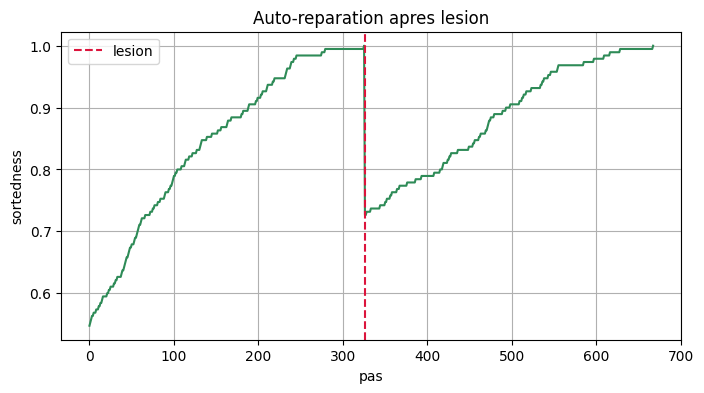

sortedness avant lesion = 1.000, juste apres = 0.726
temps de recuperation = 341 pas | etat final trie ? True


In [5]:
# --- Exemple guide : perturbation puis recuperation ---
arr = SelfSortingArray(perm(20), seed=3)
arr.run()
p_step = len(arr.probe.values) - 1     # instant juste avant la lesion
arr.perturb(n_swaps=4)                  # lesion exogene
arr.run()                               # le systeme se reorganise

srt = m.sortedness_curve(arr.probe.values)
rt = m.recovery_time(srt, perturbation_step=p_step + 1)
plt.plot(srt, color="seagreen")
plt.axvline(p_step + 1, color="crimson", ls="--", label="lesion")
plt.xlabel("pas"); plt.ylabel("sortedness"); plt.title("Auto-reparation apres lesion")
plt.legend(); plt.show()
print(f"sortedness avant lesion = {srt[p_step]:.3f}, juste apres = {srt[p_step+1]:.3f}")
print(f"temps de recuperation = {rt} pas | etat final trie ? {arr.values == sorted(arr.values)}")

**Interprétation.** Le système ne « sait » pas qu'il a été lésé — il n'a ni mémoire de l'état-cible, ni détecteur d'erreur global. Pourtant la même dynamique locale qui avait construit l'ordre le **reconstruit** après la perturbation, jusqu'au retour à l'état trié. C'est la marque d'un **attracteur** : l'ordre n'est pas un point de départ privilégié, c'est l'état vers lequel converge toute trajectoire. La régénération est gratuite — elle découle des mêmes règles que la morphogenèse initiale.

## 5. Hétérogénéité : tableaux chimériques et impasses locales

Un tableau **chimérique** mélange les algotypes. Comme `bubble` (pousse à droite) et `insertion` (tire à gauche) servent le même ordre croissant, on pourrait croire qu'un tel tableau se trie aussi. Observons ce qui se passe réellement.

In [6]:
# --- Exemple guide : un tableau chimerique alterne ---
n = 20
v = perm(n)
algos = [ALGOTYPES[i % 2] for i in range(n)]   # bubble, insertion, bubble, ...
arr = SelfSortingArray(v, algotypes=algos, seed=5)
arr.run()
print("Trie ?", arr.values == sorted(v), "| sortedness finale =", round(m.sortedness(arr.values), 3))

# une frontiere "insertion | bubble" inversee est un point fixe local :
# la cellule de gauche ne regarde qu'a gauche, celle de droite qu'a droite,
# aucune ne peut corriger l'inversion qui les separe.
deadlocks = sum(
    1 for i in range(len(arr.cells) - 1)
    if arr.cells[i].algotype == "insertion" and arr.cells[i+1].algotype == "bubble"
    and arr.cells[i].value > arr.cells[i+1].value
)
agg = m.aggregation_curve(arr.probe.algotypes)
print(f"Impasses locales residuelles (insertion|bubble inversees) : {deadlocks}")
print(f"Indice d'agregation des algotypes : initial={agg[0]:.2f}, max={max(agg):.2f}, final={agg[-1]:.2f}")

Trie ? False | sortedness finale = 0.784
Impasses locales residuelles (insertion|bubble inversees) : 4
Indice d'agregation des algotypes : initial=-0.90, max=0.20, final=0.00


**Interprétation — quand l'autonomie locale se piège elle-même.** Le tableau chimérique **ne se trie pas toujours complètement**. Une frontière `insertion | bubble` en désordre forme un **point fixe local** : la cellule de gauche ne regarde qu'à gauche, celle de droite qu'à droite — l'inversion qui les sépare n'est dans le champ de vision de personne. L'hétérogénéité, qui pourrait sembler enrichir le système, introduit ici des **échecs de coordination** qu'aucune cellule homogène ne rencontre.

> **Note d'honnêteté.** Le papier de Zhang, Goldstein & Levin rapporte une compétence *positive* supplémentaire — les cellules tendent à **s'agréger avec leurs semblables** (« kin ») pendant le voyage, sans que cela soit encodé nulle part. Notre modèle minimal à règles uni-directionnelles ne reproduit pas fidèlement cette agrégation (l'indice ci-dessus reste faible) ; il révèle plutôt la pathologie duale, l'impasse. L'agrégation chimérique sera étudiée avec un jeu de règles plus riche dans **ICT-4**. Mesurer ce que le modèle fait *vraiment*, plutôt que ce qu'on espérait, est précisément la discipline de la série ICT.

## 6. Exercices

Trois exercices pour manipuler le modèle. Les squelettes sont à compléter ; le notebook s'exécute de bout en bout même sans les remplir.

### Exercice 1 — Bubble est-il plus rapide qu'insertion ?

**Objectif.** Comparer le **coût** (nombre de swaps) pour trier le *même* tableau initial avec un tableau 100 % `bubble` puis 100 % `insertion`, moyenné sur plusieurs graines.

**Indices.**
- `# Etape 1` : fixer un tableau initial `v` (par ex. `list(np.random.default_rng(0).permutation(30))`).
- `# Etape 2` : pour `seed` dans `range(20)`, construire `SelfSortingArray(v, algotypes=[t]*len(v), seed=seed)`, `.run()`, relever `arr.probe.swaps`.
- `# Etape 3` : comparer les moyennes des deux algotypes.

In [7]:
# Exercice 1 : cout comparatif bubble vs insertion
def cout_moyen(algotype, v, n_seeds=20):
    # TODO etudiant : moyenne du nombre de swaps sur n_seeds graines
    # Indice : arr = SelfSortingArray(v, algotypes=[algotype]*len(v), seed=s).run()
    result = None  # TODO etudiant
    return result

# v = list(np.random.default_rng(0).permutation(30))
# print("bubble   :", cout_moyen("bubble", v))
# print("insertion:", cout_moyen("insertion", v))

### Exercice 2 — Variabilité de l'auto-réparation

**Objectif.** Après une lésion identique (`perturb(n_swaps=5)`), le temps de récupération dépend du hasard d'activation. Estimer sa **moyenne** et son **écart-type** sur 15 graines.

**Indices.**
- `# Etape 1` : pour chaque graine, trier, mémoriser `p_step`, perturber, re-trier.
- `# Etape 2` : `rt = m.recovery_time(m.sortedness_curve(arr.probe.values), p_step + 1)`.
- `# Etape 3` : ignorer les `None` (jamais récupéré), puis `np.mean` / `np.std`.

In [8]:
# Exercice 2 : distribution du temps de recuperation
def temps_recuperation(n_seeds=15):
    temps = []
    # TODO etudiant : remplir `temps` avec les recovery_time non-None
    pass
    return temps

# rts = temps_recuperation()
# print("recovery_time : moyenne / ecart-type") 

### Exercice 3 — Guérir l'impasse chimérique

**Objectif.** Concevoir une règle locale qui **évite les impasses** de la section 5 tout en gardant des algotypes distincts.

**Piste.** Une cellule qui, lorsqu'elle est bloquée, jette aussi un coup d'œil à son **autre** voisin briserait la frontière `insertion | bubble`. Décrire (en commentaire) la règle, puis tester l'idée en assignant les algotypes autrement (par ex. par **blocs** plutôt qu'en alternance) et mesurer la sortedness finale.

**Indices.**
- `# Etape 1` : construire `algos` par blocs : `["bubble"]*10 + ["insertion"]*10`.
- `# Etape 2` : comparer la sortedness finale à celle du tableau alterné de la section 5.
- `# Etape 3` : conclure sur le rôle de l'**agencement** des algotypes.

In [9]:
# Exercice 3 : agencement des algotypes et impasses
def sortedness_finale(algos, seed=5):
    v = list(np.random.default_rng(1).permutation(len(algos)))
    # TODO etudiant : construire l'array chimerique, le faire tourner, renvoyer m.sortedness(...)
    result = None  # TODO etudiant
    return result

# print("alterne :", sortedness_finale([ALGOTYPES[i % 2] for i in range(20)]))
# print("blocs   :", sortedness_finale(["bubble"]*10 + ["insertion"]*10))

## Conclusion et perspectives

Ce que ce toy model a rendu **mesurable**, sans aucun contrôleur global :

- une **trajectoire** dans le morphospace (inversions, sortedness, monotonie) ;
- le **délai de gratification** : sacrifices locaux au service du progrès global ;
- la **robustesse** aux cellules défectueuses (et la supériorité du régime passif) ;
- l'**auto-réparation** après lésion (l'ordre comme attracteur) ;
- les **impasses** que l'hétérogénéité introduit dans un système d'agents autonomes.

Ce sont les premières **signatures de trajectoires causales intégrées** — l'objet de la série ICT.

### Ponts avec le reste du cours
- **[IIT-1 — Intro to PyPhi](../IIT-1-IntroToPyPhi.ipynb)** et **[IIT-2 Advanced Topics](../IIT-2-AdvancedTopics.ipynb)** : les structures causales *à un instant* (TPM, Φ, CES) dont ICT étudie l'évolution.
- **ICT-1 — Φ-trajectories** (à venir) : appliquer ces idées de trajectoire à Φ lui-même.
- **ICT-4 — Chimeric arrays & emergent aggregation** (à venir) : le jeu de règles plus riche qui reproduit l'agrégation « kin » du papier.
- **ICT-6 — Sorting-to-TPM bridge** (à venir) : transformer ces simulations en chaînes de Markov, puis en TPM analysables par PyPhi et la *causal emergence*.

### Références
- Zhang, Goldstein & Levin, *Classical sorting algorithms as a model of morphogenesis*, Adaptive Behavior, 2025 — [arXiv:2401.05375](https://arxiv.org/abs/2401.05375).
- Levin, *The Computational Boundary of a "Self"*, Frontiers in Psychology, 2019 (intelligence basale, compétences à différentes échelles).
